## 0 - Importación de Librerías

Carga de librerías necesarias para el análisis de LSA con SVD:
- **pandas**: manipulación de datos y DataFrames
- **numpy**: operaciones matriciales y álgebra lineal
- **scipy**: matrices dispersas y álgebra lineal avanzada
- **matplotlib**: visualización de gráficos
- **sklearn**: vectorización TF-IDF y machine learning
- **nltk**: procesamiento de lenguaje natural (tokenización y stopwords)

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import pdist, squareform

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords


nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)


True

---
## P1 - Eleccion y descripción del corpus
- Fuente: Dataset de IMBD, obtenido de Kaggle que es de acceso publico. Acceso al Dataset: [IMBD Movies](https://www.kaggle.com/code/payamamanat/imdb-movies/input)
- Numero de documentos: para este proyecto reduciremos las descripciones de pelicula/serie a un subconjunto de $n=100$
- Descripción del corpus: el archivo contiene información de más de 7000 películas y series. El corpus tiene información como 'año'. 'duración', 'genero', 'descripción', etc. El dataset solo usara las entradas de 'genre' y 'description'.

Es interesante porque la fuente tiene una gran cantidad de datos y es considerada una herramienta esencial para investigar producciones

---
## P2 - Hipotesis inicial
Como grupo planteamos que las películas que comparten género tendrán un vocabulario parecido en sus descripciones porque cuentan con elementos o situaciones parecidas en su trama.

---
## P3 - Procesamiento del texto

In [2]:
df = pd.read_csv('IMBD.csv', delimiter=',')

In [3]:
df_cortado = df[['genre','description']].dropna().head(100)

In [4]:
df_cortado.head(5)

,genre,description
0,"Action, Comedy, Drama",Decades after their 1984 All Valley Karate Tou...
1,"Biography, Drama, History",Follows the political rivalries and romance of...
2,"Crime, Drama",The trials and tribulations of criminal lawyer...
3,"Drama, Horror, Mystery",When a psychiatrist shelters a mysterious cult...
4,"Animation, Action, Adventure",A Street Kid trying to survive in a technology...


In [5]:
len(df_cortado)

100

In [6]:
def procesar_texto(texto):
  # tokenizamos las palabras y las ponemos todas en minusculas
  tokens = word_tokenize(texto.lower())

  filtered_tokens = [token for token in tokens if token not in set(stopwords.words('english'))]

  return ' '.join(filtered_tokens)


In [7]:
df_cortado['description cleaned'] = df_cortado['description'].apply(procesar_texto)

In [8]:
df_cortado

,genre,description,description cleaned
0,"Action, Comedy, Drama",Decades after their 1984 All Valley Karate Tou...,"decades 1984 valley karate tournament bout , m..."
1,"Biography, Drama, History",Follows the political rivalries and romance of...,follows political rivalries romance queen eliz...
2,"Crime, Drama",The trials and tribulations of criminal lawyer...,trials tribulations criminal lawyer jimmy mcgi...
3,"Drama, Horror, Mystery",When a psychiatrist shelters a mysterious cult...,psychiatrist shelters mysterious cult escapee ...
4,"Animation, Action, Adventure",A Street Kid trying to survive in a technology...,street kid trying survive technology body modi...
...,...,...,...
95,"Comedy, Drama, Music","Follows Vince, a desperate former popstar who ...","follows vince , desperate former popstar dream..."
96,"Drama, Romance",A seventeen-year-old aristocrat falls in love ...,seventeen-year-old aristocrat falls love kind ...
97,"Drama, History, Romance","Wealth, lust, and betrayal set against the bac...","wealth , lust , betrayal set backdrop regency-..."
98,"Crime, Drama, Mystery",A modern update finds the famous sleuth and hi...,modern update finds famous sleuth doctor partn...


In [9]:
vectores = TfidfVectorizer()
tfidf_matrix = vectores.fit_transform(df_cortado['description cleaned'])

In [10]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1568 stored elements and shape (100, 1138)>

In [11]:
# probando
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectores.get_feature_names_out()).T
print(tfidf_df)

        0    1    2    3    4    5    6    7    8    9   ...        90   91  \
10     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.000000  0.0   
1743   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.000000  0.0   
1900s  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.000000  0.0   
1920s  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.000000  0.0   
1945   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.000000  0.0   
...    ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...       ...  ...   
young  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.138911  0.0   
youth  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.000000  0.0   
yun    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.000000  0.0   
zany   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.000000  0.0   
zaun   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.000000  0.0   

             92   93   94        95   96   97   98 

---

## P4 - Construcción de la Matriz Textual

Construimos una matriz **A ∈ ℝ^(m×n)** donde:
- **m** = número de términos únicos (palabras)
- **n** = número de documentos (películas)
- **Filas** = términos | **Columnas** = documentos  
- Cada entrada **A_ij** = peso TF-IDF del término i en el documento j

usamos la convención:
$$A = U \Sigma V^T$$

Donde la matriz **A** tiene términos en filas y documentos en columnas.

In [12]:
# Construcción de la matriz textual (P4)

print("Matriz textual término-documento")

# El vectorizador crea documentos en filas, términos en columnas
# Necesitamos transponerla para seguir la convención: términos en filas
vectorizador_tfidf = TfidfVectorizer()
matriz_doc_palabra = vectorizador_tfidf.fit_transform(df_cortado['description cleaned'])

# Transposición: filas = términos, columnas = documentos
A = matriz_doc_palabra.T

print(f"Dimensiones de A: {A.shape[0]} x {A.shape[1]}")
print(f"m (términos): {A.shape[0]}")
print(f"n (documentos): {A.shape[1]}")
print("Matriz: TF-IDF")
sparsidad = (1 - A.nnz / (A.shape[0] * A.shape[1])) * 100
print(f"Sparsidad: {sparsidad:.1f}%")

# Información sobre el vocabulario
feature_names = vectorizador_tfidf.get_feature_names_out()
print(f"Vocabulario total: {len(feature_names)}")

# Mostramos ejemplos de palabras importantes en el primer documento
doc_0 = A.getcol(0).toarray().flatten()
top_5_indices = np.argsort(doc_0)[-5:][::-1]
print("Primer documento: términos con mayor peso")
for idx in top_5_indices:
    if doc_0[idx] > 0:
        print(f"{feature_names[idx]}: {doc_0[idx]:.4f}")

print("Matriz A construida")

Matriz textual término-documento
Dimensiones de A: 1138 x 100
m (términos): 1138
n (documentos): 100
Matriz: TF-IDF
Sparsidad: 98.6%
Vocabulario total: 1138
Primer documento: términos con mayor peso
larusso: 0.2597
1984: 0.2597
aged: 0.2597
martial: 0.2597
lawrence: 0.2597
Matriz A construida


---

## P5 - Cálculo de la Descomposición en Valores Singulares (SVD)

Calculamos: $$A = U \Sigma V^T$$

Donde:
- **U ∈ ℝ^(m×m)**: Vectores singulares izquierdos
  - Columnas = direcciones principales en el **espacio de TÉRMINOS**
  - Interpretación: qué términos van juntos semánticamente
  
- **Σ**: Matriz diagonal con valores singulares σ₁ ≥ σ₂ ≥ ... ≥ σₙ
  - Representan la **importancia** de cada dirección/componente
  - Valores grandes = componentes que capturan mucha varianza
  
- **V^T ∈ ℝ^(n×n)**: Vectores singulares derechos
  - Filas = direcciones principales en el **espacio de DOCUMENTOS**
  - Interpretación: cómo se proyectan los documentos en cada dirección

### Interpretación Semántica
Cada valor singular σᵢ representa un "tema latente" capturado por el análisis:
- **σ₁** (mayor): El tema más importante del corpus
- **σ₂**: El segundo tema más relevante
- Y así sucesivamente...

La SVD descompone la matriz TF-IDF en componentes que representan la estructura semántica oculta del corpus.

In [13]:
# Descomposición en valores singulares (P5)

print("Descomposición SVD")

# Convertimos a matriz densa para calcular SVD
A_densa = A.toarray()

# Calculamos la SVD completa: A = U * Σ * V^T
print("Calculando SVD...")
U, sigma, VT = np.linalg.svd(A_densa, full_matrices=False)
print("SVD calculada")

# Mostrar dimensiones
print(f"U: {U.shape}")
print(f"Sigma: {len(sigma)}")
print(f"VT: {VT.shape}")

# Mostramos los primeros valores singulares
print("Primeros 10 valores singulares:")
for i in range(min(10, len(sigma))):
    print(f"sigma_{i+1}: {sigma[i]:.6f}")

# Verificamos que la reconstrucción sea correcta
A_reconstruida = U @ np.diag(sigma) @ VT
error_reconstruccion = np.linalg.norm(A_densa - A_reconstruida) / np.linalg.norm(A_densa)
print(f"Error de reconstruccion: {error_reconstruccion:.2e}")

print("Interpretacion:")
print("Los valores singulares grandes capturan mas estructura del corpus.")
print("U describe relaciones entre terminos.")
print("VT describe relaciones entre documentos.")

Descomposición SVD
Calculando SVD...
SVD calculada
U: (1138, 100)
Sigma: 100
VT: (100, 100)
Primeros 10 valores singulares:
sigma_1: 1.460433
sigma_2: 1.300153
sigma_3: 1.234429
sigma_4: 1.219588
sigma_5: 1.202352
sigma_6: 1.183213
sigma_7: 1.168272
sigma_8: 1.161831
sigma_9: 1.156779
sigma_10: 1.148194
Error de reconstruccion: 2.72e-15
Interpretacion:
Los valores singulares grandes capturan mas estructura del corpus.
U describe relaciones entre terminos.
VT describe relaciones entre documentos.


## P6 - Análisis de Valores Singulares y Elección de Dimensión Reducida

### Objetivo
Determinar un número de componentes (k) razonable que nos permita capturar los conceptos semánticos latentes principales del corpus, descartando el ruido del vocabulario.

### Estrategia: Método del Codo
- En LSA aplicado a matrices TF-IDF (que son altamente dispersas), buscar un porcentaje de varianza acumulada muy alto (ej. 90%) suele ser contraproducente, ya que obliga a retener una gran cantidad de componentes que solo representan "ruido" (palabras de muy baja frecuencia o sinónimos sueltos).
- **Nuestra estrategia:** Graficaremos el decaimiento de los valores singulares y buscaremos el "codo" de la curva (el punto donde la caída abrupta se detiene y comienza a aplanarse).
- Reducir la matriz a este $k$ óptimo nos permite:
  - Forzar al modelo a agrupar semánticamente los términos relacionados ✓
  - Filtrar el ruido y evitar el overfitting ✓
  - Reducir significativamente la dimensionalidad y complejidad computacional ✓

Analisis de valores singulares
Varianza explicada por componente:
  i    sigma_i    var_rel   var_acum
  1     1.4604       2.1%       2.1%
  2     1.3002       1.7%       3.8%
  3     1.2344       1.5%       5.3%
  4     1.2196       1.5%       6.8%
  5     1.2024       1.4%       8.3%
  6     1.1832       1.4%       9.7%
  7     1.1683       1.4%      11.0%
  8     1.1618       1.3%      12.4%
  9     1.1568       1.3%      13.7%
 10     1.1482       1.3%      15.1%
 11     1.1328       1.3%      16.3%
 12     1.1233       1.3%      17.6%
 13     1.1188       1.3%      18.8%
 14     1.1136       1.2%      20.1%
 15     1.1088       1.2%      21.3%


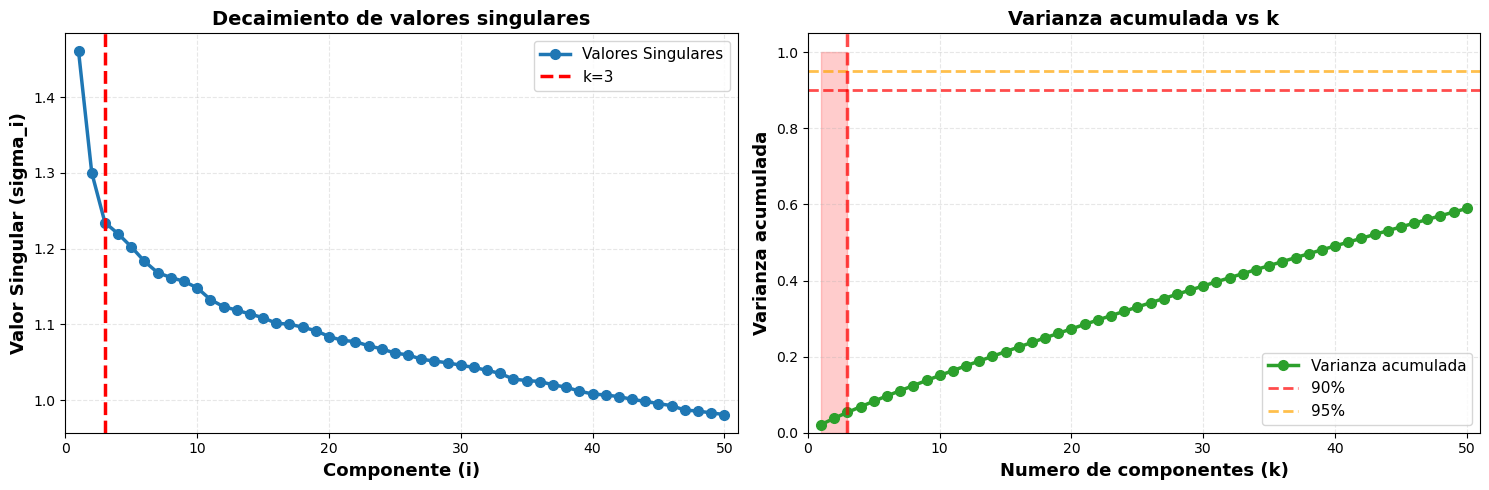


Interpretacion de los graficos:
La eleccion recomendada es k = 3, porque corresponde al 'codo' del gráfico de decaimiento.
En LSA para matrices TF-IDF (que son muy dispersas), elegir este punto nos permite capturar los conceptos latentes principales y forzar la agrupación semántica.
No buscamos un porcentaje de varianza alto (ej. 90%), ya que eso obligaría a retener una gran cantidad de componentes que solo representan ruido o palabras de muy baja frecuencia.


In [14]:
# Análisis de valores singulares y elección de dimensión (P6)

print("Analisis de valores singulares")

# Calculamos la varianza explicada por cada componente
# Varianza relativa: σᵢ² / suma(σⱼ²)
varianza_relativa = (sigma ** 2) / np.sum(sigma ** 2)
varianza_acumulada = np.cumsum(varianza_relativa)

print("Varianza explicada por componente:")
print(f"{'i':>3} {'sigma_i':>10} {'var_rel':>10} {'var_acum':>10}")
for i in range(min(15, len(sigma))):
    print(f"{i+1:3d} {sigma[i]:10.4f} {varianza_relativa[i]:10.1%} {varianza_acumulada[i]:10.1%}")


# Basado en la observación visual del gráfico de decaimiento (método del codo)
k_optimo = 3

# Crear visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Decaimiento de valores singulares
n_show = min(50, len(sigma))
axes[0].plot(range(1, n_show+1), sigma[:n_show], 'o-', linewidth=2.5, markersize=7,
             color='#1f77b4', label='Valores Singulares')
axes[0].axvline(x=k_optimo, color='red', linestyle='--', linewidth=2.5, label=f'k={k_optimo}')
axes[0].set_xlabel('Componente (i)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valor Singular (sigma_i)', fontsize=13, fontweight='bold')
axes[0].set_title('Decaimiento de valores singulares', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].legend(fontsize=11)
axes[0].set_xlim([0, n_show+1])

# Gráfico 2: Varianza acumulada
n_show_var = min(50, len(varianza_acumulada))
axes[1].plot(range(1, n_show_var+1), varianza_acumulada[:n_show_var], 'o-', linewidth=2.5,
             markersize=7, color='#2ca02c', label='Varianza acumulada')
axes[1].axhline(y=0.90, color='red', linestyle='--', linewidth=2, alpha=0.7, label='90%')
axes[1].axhline(y=0.95, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='95%')
axes[1].axvline(x=k_optimo, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
axes[1].fill_between(range(1, k_optimo+1), 0, 1, alpha=0.2, color='red')
axes[1].set_xlabel('Numero de componentes (k)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Varianza acumulada', fontsize=13, fontweight='bold')
axes[1].set_title('Varianza acumulada vs k', fontsize=14, fontweight='bold')
axes[1].set_xlim([0, n_show_var+1])
axes[1].set_ylim([0, 1.05])
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("\nInterpretacion de los graficos:")
print(f"La eleccion recomendada es k = {k_optimo}, porque corresponde al 'codo' del gráfico de decaimiento.")
print("En LSA para matrices TF-IDF (que son muy dispersas), elegir este punto nos permite capturar los conceptos latentes principales y forzar la agrupación semántica.")
print("No buscamos un porcentaje de varianza alto (ej. 90%), ya que eso obligaría a retener una gran cantidad de componentes que solo representan ruido o palabras de muy baja frecuencia.")

In [15]:
# Matrices reducidas (P6 - Continuación)

# Seleccionar la dimensión k elegida
k = k_optimo

# Crear matrices reducidas
U_k = U[:, :k]
sigma_k = sigma[:k]
VT_k = VT[:k, :]

print("Matrices reducidas")
print(f"k = {k}")
print(f"Varianza capturada: {varianza_acumulada[k-1]:.1%}")

print(f"U_k: {U_k.shape}")
print(f"Sigma_k: {len(sigma_k)}")
print(f"VT_k: {VT_k.shape}")

# Reconstrucción con dimensión reducida
A_k = U_k @ np.diag(sigma_k) @ VT_k
error_reducido = np.linalg.norm(A_densa - A_k) / np.linalg.norm(A_densa)

print(f"Error de reconstruccion: {error_reducido:.4f}")
print(f"Elementos originales: {A_densa.size:,}")
print(f"Elementos reducidos: {U_k.size + len(sigma_k) + VT_k.size:,}")
print(f"Compresion: {(1 - (U_k.size + len(sigma_k) + VT_k.size) / A_densa.size) * 100:.1f}%")

print("Resumen P4-P6")
print("Matriz textual construida")
print("SVD calculada")
print(f"Dimension reducida elegida: k = {k}")

Matrices reducidas
k = 3
Varianza capturada: 5.3%
U_k: (1138, 3)
Sigma_k: 3
VT_k: (3, 100)
Error de reconstruccion: 0.9729
Elementos originales: 113,800
Elementos reducidos: 3,717
Compresion: 96.7%
Resumen P4-P6
Matriz textual construida
SVD calculada
Dimension reducida elegida: k = 3


## P7 - Representación de documentos y términos en baja dimensión

En esta sección construiremos una representación en dos dimensiones usando las dos primeras componentes de la SVD.

Como la matriz textual fue construida con la convención **término-documento**, las coordenadas de los documentos se obtienen con:

$$
D_2 = \Sigma_2 V_2^T
$$

Mientras que las coordenadas de los términos se obtienen con:

$$
T_2 = U_2 \Sigma_2
$$

El objetivo es hacer dos visualizaciones:

1. Un gráfico donde cada punto representa una película o serie.
2. Un gráfico donde cada punto representa una palabra relevante.

Luego observaremos si las películas con vocabulario similar aparecen cercanas y si existen palabras que se agrupan alrededor de temas parecidos.

In [16]:
print("P7 - Representación en baja dimensión:")

#Seleccionamos los dos primeros componentes
componente_1 = 0
componente_2 = 1

# Coordenadas de documentos:
# D2 = Sigma_2 * V2^T
D2 = np.vstack([
    sigma[componente_1] * VT[componente_1, :],
    sigma[componente_2] * VT[componente_2, :]
])

# Coordenadas de términos:
# T2 = U2 * Sigma_2
T2 = np.column_stack([
    sigma[componente_1] * U[:, componente_1],
    sigma[componente_2] * U[:, componente_2]
])

print(f"D2 documentos: {D2.shape}")
print(f"T2 términos: {T2.shape}")

P7 - Representación en baja dimensión:
D2 documentos: (2, 100)
T2 términos: (1138, 2)


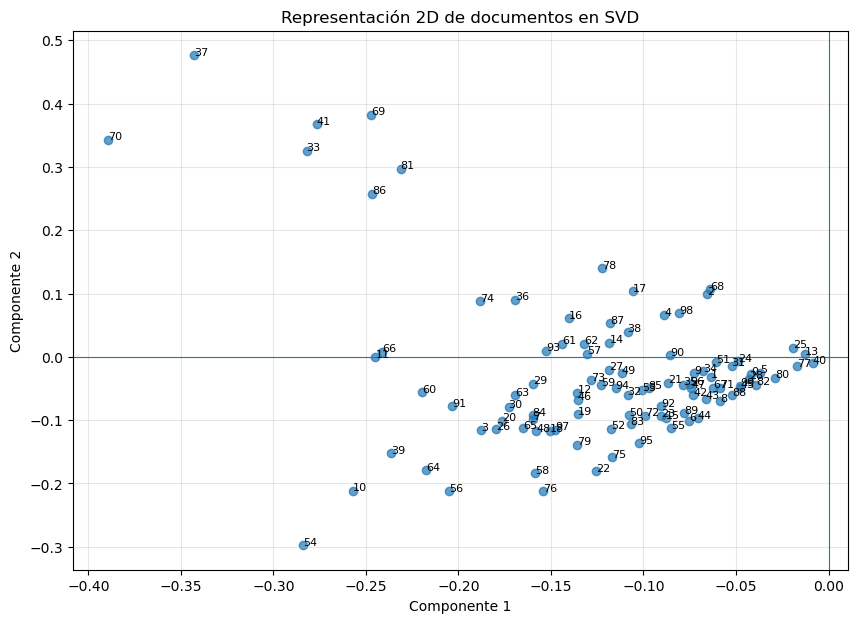

In [17]:
# Visualización 2D de documentos
plt.figure(figsize=(10, 7))
plt.scatter(D2[0, :], D2[1, :], alpha=0.7)

# Le ponemos a cada documento su índice
for i in range(D2.shape[1]):
    plt.text(D2[0, i], D2[1, i], str(i), fontsize=8)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.title("Representación 2D de documentos en SVD")

plt.grid(alpha=0.3)
plt.show()

In [18]:
tabla_documentos = df_cortado[['genre', 'description']].copy()
tabla_documentos['id_documento'] = range(len(tabla_documentos))

# Ordenamos las columnas
tabla_documentos = tabla_documentos[['id_documento', 'genre', 'description']]
tabla_documentos.head(10)

,id_documento,genre,description
0,0,"Action, Comedy, Drama",Decades after their 1984 All Valley Karate Tou...
1,1,"Biography, Drama, History",Follows the political rivalries and romance of...
2,2,"Crime, Drama",The trials and tribulations of criminal lawyer...
3,3,"Drama, Horror, Mystery",When a psychiatrist shelters a mysterious cult...
4,4,"Animation, Action, Adventure",A Street Kid trying to survive in a technology...
5,5,"Drama, Fantasy, Horror",Upon escaping after decades of imprisonment by...
6,6,"Animation, Adventure, Comedy",An animated series that follows the exploits o...
7,7,"Crime, Drama, Thriller",A high school chemistry teacher diagnosed with...
8,8,"Action, Adventure, Drama",After an experimental gene therapy turns them ...
9,9,"Biography, Drama, Mystery",A fictionalized chronicle of the inner life of...


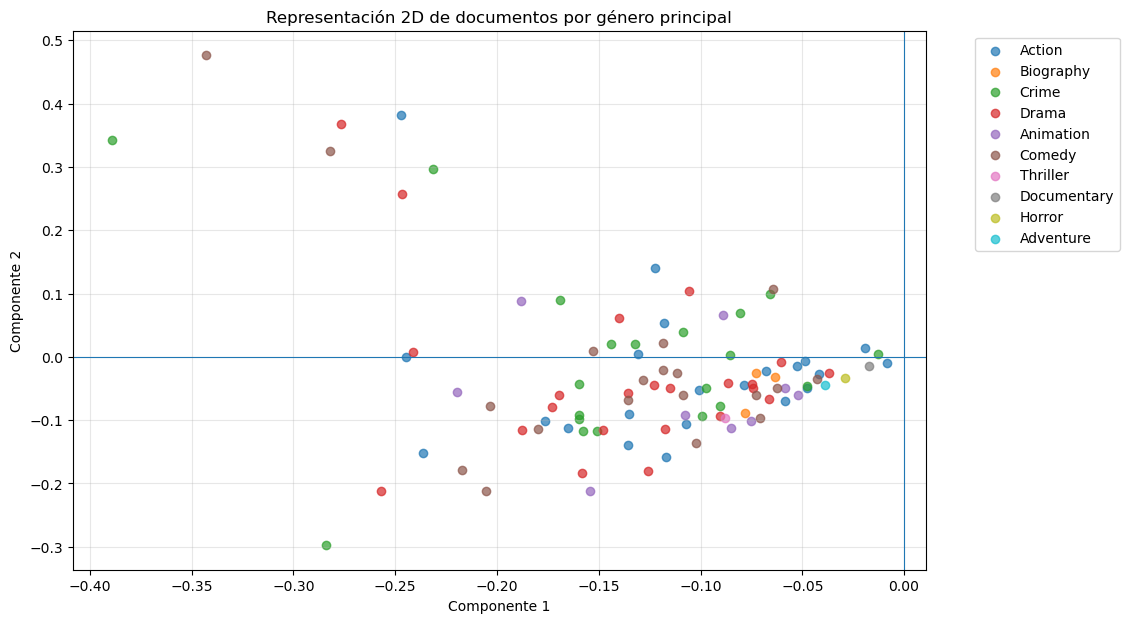

In [19]:
# Creamos una columna con el primer género de cada pelicula
df_cortado['genero_principal'] = df_cortado['genre'].apply(lambda x: str(x).split(',')[0].strip())
df_cortado[['genre', 'genero_principal']].head()

# Visualización 2D de documentos pintados por género principal
generos = df_cortado['genero_principal'].unique()

plt.figure(figsize=(11, 7))
for genero in generos:
    indices = df_cortado[df_cortado['genero_principal'] == genero].index
    plt.scatter(
        D2[0, indices],
        D2[1, indices],
        label=genero,
        alpha=0.7
    )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.title("Representación 2D de documentos por género principal")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()

### Interpretación de la visualización de documentos

En el gráfico coloreado por género se observa que los documentos no forman grupos completamente separados según su género principal. Varios colores aparecen mezclados en la zona central del plano, lo que indica que las dos primeras componentes de la SVD no separan perfectamente las películas por género.

Esto sugiere que la hipótesis inicial se cumple solo parcialmente: algunas películas pueden compartir vocabulario por género, pero también existen descripciones de géneros distintos que usan palabras similares. Además, algunos puntos aparecen alejados del grupo principal, lo que indica que esas películas tienen descripciones con un vocabulario más diferente.

In [20]:
#Elegimos los términos más relevantes para graficar
normas_terminos = np.linalg.norm(T2, axis=1)

# Elegimos los 30 términos más alejados del origen
n_terminos = 30
indices_relevantes = np.argsort(normas_terminos)[-n_terminos:]
terminos_relevantes = feature_names[indices_relevantes]

print("Términos relevantes elegidos:")
for termino in terminos_relevantes:
    print(termino)

Términos relevantes elegidos:
boy
four
high
apart
lives
father
supernatural
children
fights
school
world
cops
revolves
follows
life
lawyer
mother
neurotic
around
must
young
two
one
town
friends
set
city
family
york
new


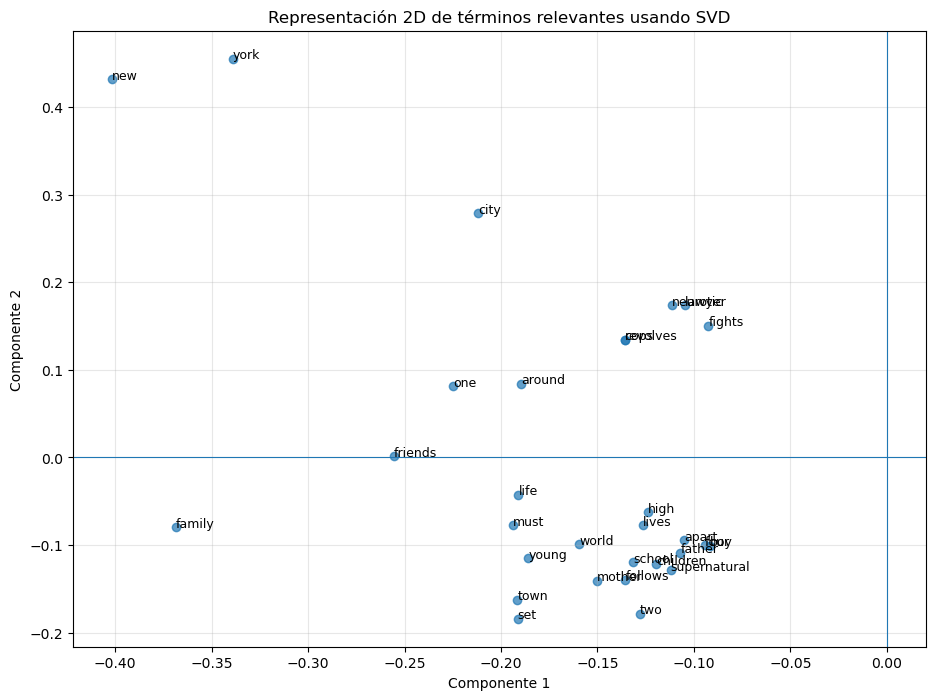

In [21]:
# Hacemos la visualización 2D para términos relevantes

plt.figure(figsize=(11, 8))
plt.scatter(
    T2[indices_relevantes, 0],
    T2[indices_relevantes, 1],
    alpha=0.7
)

for i in indices_relevantes:
    plt.text(
        T2[i, 0],
        T2[i, 1],
        feature_names[i],
        fontsize=9
    )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.title("Representación 2D de términos relevantes usando SVD")

plt.grid(alpha=0.3)
plt.show()

In [22]:
# Tabla de términos relevantes con las coordenadas

tabla_de_terminos = pd.DataFrame({
    'termino': feature_names,
    'componente_1': T2[:, 0],
    'componente_2': T2[:, 1],
    'norma': normas_terminos
})

tabla_terminos_relevantes = tabla_de_terminos.sort_values('norma', ascending=False).head(30)
tabla_terminos_relevantes.head(10)

,termino,componente_1,componente_2,norma
711,new,-0.401774,0.431403,0.589518
1132,york,-0.338961,0.454908,0.567306
380,family,-0.368433,-0.079264,0.376863
175,city,-0.212030,0.278618,0.350121
894,set,-0.191375,-0.183951,0.265447
427,friends,-0.255722,0.001727,0.255728
1026,town,-0.191451,-0.162072,0.250840
732,one,-0.224795,0.081163,0.238999
1049,two,-0.128128,-0.178256,0.219527
1133,young,-0.185800,-0.115155,0.218592


### Interpretación de la visualización de términos

A partir de la visualización de términos relevantes, se observa que las palabras más alejadas del origen son las que tienen mayor peso en las dos primeras componentes. Estas palabras ayudan a interpretar los posibles temas latentes del corpus.

Si aparecen términos relacionados entre sí en zonas cercanas del gráfico, esto puede indicar que suelen aparecer en contextos similares dentro de las descripciones. Por ejemplo, palabras asociadas a crimen, acción, familia o romance pueden revelar grupos temáticos presentes en las películas.

## P8 - Exploración semántica

En esta sección usamos la representación reducida obtenida con SVD para explorar relaciones semánticas dentro del corpus. La idea es revisar ejemplos concretos de documentos cercanos, términos cercanos y posibles temas asociados a las componentes principales.

In [23]:
documentos_2d = D2.T

# Calculamos la distancia euclidiana para ver cuales documentos se parecen más entre sí
distancias = squareform(pdist(documentos_2d, metric='euclidean'))

# Para que no caclulemos dos veces un mismo documentro entre sí
np.fill_diagonal(distancias, np.inf)

pares_distancia = []
for i in range(distancias.shape[0]):
    for j in range(i + 1, distancias.shape[1]):
        pares_distancia.append((i, j, distancias[i, j]))

# Ordenamos desde los más cercanos
pares_cercanos = sorted(pares_distancia, key=lambda x: x[2])
pares_cercanos[:10]

[(18, 97, np.float64(0.0034672297956672023)),
 (45, 99, np.float64(0.0034740731610584975)),
 (67, 71, np.float64(0.0036467750191630905)),
 (15, 23, np.float64(0.0038030446595865614)),
 (35, 96, np.float64(0.004107875068422821)),
 (53, 85, np.float64(0.004862080692209268)),
 (9, 34, np.float64(0.005318435158519124)),
 (6, 44, np.float64(0.005658911125502058)),
 (0, 5, np.float64(0.005783989035865902)),
 (47, 96, np.float64(0.0059250063472774))]

In [24]:
#Elegimos los documentos que más se parecen, el que salio primero en nuestros pares ordenados en este caso.
documento_a = 18
documento_b = 97

pd.set_option('display.max_colwidth', None)
tabla_documentos.loc[[documento_a, documento_b]]

,id_documento,genre,description
18,18,"Crime, Drama","A gangster family epic set in 1900s England, centering on a gang who sew razor blades in the peaks of their caps, and their fierce boss Tommy Shelby."
97,97,"Drama, History, Romance","Wealth, lust, and betrayal set against the backdrop of Regency-era England, seen through the eyes of the powerful Bridgerton family."


### Ejemplo 1: Documentos cercanos
Uno de los pares más cercanos en la representación 2D corresponde a los documentos 97 y 18.
Al ver ambas descripciones podemos notar varias similitudes: ambas pertencen al género drama, las dos se desarollan en Inglaterra y presentan historias "similares" al estar asociadas a familias, poder y conflictos sociales
Esto nos da una coherencia con la representación que obtuvimos, ya que la cercanía entre ambos puntos indican que sus descripciones comparten patrones de vocabulario similares.

In [ ]:
T2_relevantes = T2[indices_relevantes]
terminos_relevantes = feature_names[indices_relevantes]

# Calculamos similitud entre los términos relevantes
sim_terminos = cosine_similarity(T2_relevantes)


np.fill_diagonal(sim_terminos, -1)

pares_terminos = []

for i in range(sim_terminos.shape[0]):
    for j in range(i + 1, sim_terminos.shape[1]):
        pares_terminos.append((
            terminos_relevantes[i],
            terminos_relevantes[j],
            sim_terminos[i, j]
        ))

pares_terminos_ordenados = sorted(
    pares_terminos,
    key=lambda x: x[2],
    reverse=True
)

tabla_pares_terminos = pd.DataFrame(
    pares_terminos_ordenados[:20],
    columns=['termino_1', 'termino_2', 'similitud']
)

tabla_pares_terminos

,termino_1,termino_2,similitud
0,cops,revolves,1.000000
1,world,young,1.000000
2,father,children,0.999998
3,apart,school,0.999993
4,children,follows,0.999992
5,lives,young,0.999984
6,father,follows,0.999981
7,lives,world,0.999980
8,life,family,0.999978
9,fights,lawyer,0.999955


### Ejemplo 2: Términos cercanos
En la representación reducida se observa que los términos **“father”** y **“children”** aparecen muy cercanos, con una similitud a 1. Esto sugiere que ambos términos aparecen en contextos parecidos dentro de las descripciones del corpus.

Esta relación es coherente, ya que ambas palabras están asociadas a historias familiares, conflictos entre padres e hijos o narrativas centradas en vínculos familiares.

Esto muestra que la SVD puede capturar asociaciones semánticas entre términos, ya que palabras que no son idénticas pero pertenecen a un mismo campo temático aparecen cercanas en el espacio reducido.

Pero también podemos ver que no todos los pares son igualmente interpretables.

In [26]:
# Palabras más importantes en las primeras componentes
def mostrar_terminos_componente(U, sigma, feature_names, componente, n=15):
    pesos = U[:, componente] * sigma[componente]
    
    positivos = np.argsort(pesos)[-n:][::-1]
    negativos = np.argsort(pesos)[:n]
    
    tabla_pos = pd.DataFrame({
        'termino': feature_names[positivos],
        'peso': pesos[positivos]
    })
    
    tabla_neg = pd.DataFrame({
        'termino': feature_names[negativos],
        'peso': pesos[negativos]
    })
    
    print(f"Componente {componente + 1} - términos con peso positivo")
    display(tabla_pos)
    
    print(f"Componente {componente + 1} - términos con peso negativo")
    display(tabla_neg)

mostrar_terminos_componente(U, sigma, feature_names, componente=0, n=15)
mostrar_terminos_componente(U, sigma, feature_names, componente=1, n=15)

Componente 1 - términos con peso positivo


,termino,peso
0,alfred,-0.001520
1,saxon,-0.001520
2,claim,-0.001520
3,birthright,-0.001520
4,seeks,-0.001520
5,norse,-0.001520
6,born,-0.001520
7,kingdom,-0.001520
8,uhtred,-0.001520
9,defends,-0.001520


Componente 1 - términos con peso negativo


,termino,peso
0,new,-0.401774
1,family,-0.368433
2,york,-0.338961
3,friends,-0.255722
4,one,-0.224795
5,city,-0.212030
6,must,-0.193827
7,town,-0.191451
8,set,-0.191375
9,life,-0.190939


Componente 2 - términos con peso positivo


,termino,peso
0,york,0.454908
1,new,0.431403
2,city,0.278618
3,neurotic,0.173637
4,lawyer,0.173606
5,fights,0.150324
6,cops,0.134409
7,revolves,0.134409
8,firm,0.105769
9,stand,0.103951


Componente 2 - términos con peso negativo


,termino,peso
0,set,-0.183951
1,two,-0.178256
2,town,-0.162072
3,mother,-0.140489
4,follows,-0.139338
5,supernatural,-0.128638
6,children,-0.121836
7,school,-0.119146
8,young,-0.115155
9,father,-0.108638


### Ejemplo 3: interpretación de componentes

Para interpretar las componentes, se revisaron los términos con mayor peso positivo y negativo en las dos primeras componentes de la SVD. Estos términos permiten aproximar qué tipo de tema o patrón de vocabulario está capturando cada eje.

En la componente 1 aparecen términos como **family**, **work**, **friends**, **city**, **life**, **young** y **mother**. Esto sugiere que esta componente está relacionada con historias de vida cotidiana, relaciones familiares, amistades y conflictos personales. Esta interpretación es coherente con el corpus, ya que muchas películas y series presentan descripciones centradas en relaciones sociales o familiares.

En la componente 2 aparecen términos positivos como **york**, **city**, **lawyer**, **fights**, **cops**, **firm**, **daredevil**, **murdock** y **night**. Estos términos sugieren un eje asociado a historias urbanas, crimen, justicia, abogados o acción. En cambio, en el lado negativo de la misma componente aparecen términos como **mother**, **children**, **school**, **young**, **father**, **boy** y **supernatural**, que se relacionan más con familia, juventud, escuela o elementos sobrenaturales.

Por lo tanto, la componente 2 parece separar parcialmente un vocabulario urbano/criminal de un vocabulario más familiar, juvenil o sobrenatural. Sin embargo, esta interpretación debe tomarse con cuidado, ya que una componente de la SVD no siempre representa un tema puro, sino una combinación de patrones de vocabulario presentes en el corpus.

## P9 - Discusión, limitaciones y conclusiones

La hipótesis inicial del proyecto planteaba que las películas y series pertenecientes a géneros similares tendrían descripciones con vocabularios parecidos. Por lo tanto, se esperaba que, al aplicar LSA con SVD, los documentos que pertenecián a un mismo género aparecieran cercanos en la representación reducida.

A raíz de las visualizaciones obtenidas, la hipótesis se cumple parcialmente. En el gráfico de documentos coloreado por género se observa que algunos documentos con temas similares aparecen cercanos, pero no se forman grupos completamente separados según el género principal. Varios géneros aparecen mezclados en la zona central del gráfico, lo que indica que las dos primeras componentes de la SVD no capturan una separación perfecta por género.

Un resultado esperado fue que algunos documentos con elementos narrativos similares aparecieran cercanos en el espacio reducido. Por ejemplo, los documentos 18 y 97 quedaron muy próximos. Al revisar sus descripciones, ambos presentan elementos de drama, se desarrollan en Inglaterra y tratan temas asociados a familias, poder y conflictos sociales. Esto muestra que la representación reducida sí puede capturar ciertas similitudes semánticas entre descripciones.

Un resultado inesperado fue que la separación por género no fue clara. En la visualización 2D, documentos de géneros distintos aparecen mezclados, especialmente en la zona central del gráfico. Esto puede deberse a que muchas descripciones comparten vocabulario general, aunque pertenezcan a géneros diferentes. Por ejemplo, palabras relacionadas con familia, vida, ciudad o conflictos pueden aparecer tanto en dramas como en comedias, acción o romance.

La interpretación de las componentes también mostró patrones interesantes. La componente 1 parece asociarse a vocabulario de vida cotidiana y relaciones personales, con términos como **family**, **work**, **friends**, **life**, **young** y **mother**. Por otro lado, la componente 2 parece separar parcialmente un vocabulario más urbano, criminal o de acción, con términos como **york**, **city**, **lawyer**, **fights**, **cops** y **night**, de otro vocabulario más familiar, juvenil o sobrenatural, con palabras como **children**, **school**, **father**, **boy** y **supernatural**.

Una primera limitación es que la visualización se hizo usando solo dos componentes. Esto permite graficar los documentos y términos en un plano, pero también implica perder información de otras componentes que podrían capturar diferencias importantes entre géneros.

Otra limitación es que LSA se basa en patrones de palabras, no en una comprensión profunda del significado. Por eso, dos documentos pueden aparecer cerca porque comparten vocabulario, aunque sus historias no sean exactamente del mismo tipo.

Además, muchas películas y series tienen más de un género, pero en la visualización se usó solo el género principal. Esto simplifica el análisis y puede ocultar relaciones más complejas entre documentos que combinan drama, acción, comedia, crimen o romance.

También se trabajó con un subconjunto de 100 documentos, por lo que los resultados no necesariamente representan todo el dataset original. Con más documentos, podrían aparecer patrones más estables o grupos temáticos más claros.

En conclusión, el uso de LSA con SVD permitió construir una representación reducida útil para explorar relaciones entre películas, series y términos relevantes. Aunque la separación por género no fue perfecta, el análisis sí permitió encontrar documentos cercanos con elementos narrativos similares y términos asociados a temas como familia, vida cotidiana, ciudad, crimen y acción.

Por lo tanto, LSA funcionó como una herramienta exploratoria para descubrir patrones generales en las descripciones, pero sus resultados deben interpretarse con cuidado y complementarse con la lectura directa del corpus.